<a href="https://colab.research.google.com/github/joanby/trading-algoritmico-dl/blob/main/ES_DL_Cap%C3%ADtulo_06_Backtesting_Vectorizado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p><img alt="Colaboratory logo" height="45px" src="https://www.quantreo.com/wp-content/uploads/2021/10/Original-on-Transparent.png" align="left" hspace="10px" vspace="0px">
<img alt="Colaboratory logo" height="45px" src="https://static-881c.kxcdn.com/wp-content/uploads/2016/03/frogamesLogoFull4.png" align="left" hspace="10px" vspace="0px"></p>

# BackTesting Vectorizado
El backtesting es una parte esencial del trading. En efecto, es importante comprender el comportamiento de nuestra estrategia en el pasado para poder considerar los del futuro.

### Contenido

* Sortino Beta Alpha
* Drawdown 
* Crear la función BackTest para evaluar la estrategia en las secciones posteriores

</br>


💰 Únete a la comunidad de [Discord](https://discord.gg/z3dx5XpkX4)

📚 Puedes leer nuestro libro en [Amazon](https://www.amazon.es/Python-para-finanzas-trading-algor%C3%ADtmico-ebook/dp/B0BT4ZS9Q3/)

🖥️ El canal de [YouTube de Quantreo's](https://www.youtube.com/channel/UCp7jckfiEglNf_Gj62VR0pw) (en inglés) y el de [Frogames](https://www.youtube.com/channel/UCMUxXNYrVCv6-bQakhomvBg) en español


### Entorno

In [1]:
!pip install yfinance    
!pip install ta

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 62 kB 1.3 MB/s 
  Attempting uninstall: requests
    Found existing installation: requests 2.23.0
    Uninstalling requests-2.23.0:
      Successfully uninstalled requests-2.23.0
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Created wheel for ta: filename=ta-0.10.2-py3-none-any.whl size=29104 sha256=1a98a4771d5aa3f750081b5c50b29840b1474fc823ad8dcb13d7fae5155527d0
  Stored in directory: /root/.cache/pip/wheels/31/31/f1/f2ff471bbc5b84a4b973698ceecdd453ae043971791adc3431
Successfully built ta


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import ta
import yfinance as yf
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
from matplotlib import cycler

colors = cycler('color',
                ['#669FEE', '#66EE91', '#9988DD',
                 '#EECC55', '#88BB44', '#FFBBBB'])
plt.rc('figure', facecolor='#313233')
plt.rc('axes', facecolor="#313233", edgecolor='none',
       axisbelow=True, grid=True, prop_cycle=colors,
       labelcolor='gray')
plt.rc('grid', color='474A4A', linestyle='solid')
plt.rc('xtick', color='gray')
plt.rc('ytick', direction='out', color='gray')
plt.rc('legend', facecolor="#313233", edgecolor="#313233")
plt.rc("text", color="#C9C9C9")
plt.rc('figure', facecolor='#313233')

# Sección 1: Sortino Beta Alpha

###### Sortino
El índice de Sortino es una estadística similar al índice de Sharpe con la misma interpretación. Sin embargo, el cálculo es ligeramente diferente. En efecto, en el índice de Sortino sólo se tiene en cuenta la volatilidad de las ganancias negativas porque es lo que tememos y no las ganancias alcistas que nos hacen ganar dinero. <br>
<p align="center">
$Sortino = \frac{\mu }{\sigma_{down}}$
<p> <br>

* SortinoRatio < 0 : Inversión no rentable porque las ganancias son negativas.
* SortinoRatio < 1: Inversión rentable, pero el riesgo de la inversión es mayor que la rentabilidad.
* SortinoRatio > 1: Inversión muy rentable porque el riesgo es menor que el rendimiento.


In [3]:
# Preparar los datos 
f = yf.download("GOOG", end="2021-01-01", auto_adjust=False, multi_level_index=False, period="max")
return_serie = f["Adj Close"].pct_change(1).dropna()
return_serie.name = "return"

# Calcular el índice de Sortino
mean = np.mean(return_serie) #252
vol = np.std(return_serie[return_serie<0]) #np.sqrt(252)
sortino = np.sqrt(252)*mean/vol

print(f"Sortino: {'%.3f' % sortino}")

[*********************100%***********************]  1 of 1 completed
Sortino: 1.232


###### Beta
La beta es un estadístico que indica la relación entre las variaciones de nuestra cartera y las del mercado que está representado por un índice (por ejemplo el SP500). <br>

<p align="center">
$Beta = \frac{Cov(r_{M},r_{PF}) }{Var(r_{M})}$
<p> <br>



* abs(Beta) < 1: Es bueno porque significa que la cartera tiene una variación menor que el índice. (Si beta=0,9 significa que si el índice varía en 1 la cartera varía en 0,9)
* abs(Beta) > 1: No es bueno porque significa que slau cartera tiene una variación mayor que el índice. (Si beta=1,1 significa que si el índice varía de 1 la cartera varía en 1,1)

*abs(-x) = x = abs(x) (abs da sólo el valor de la variable no el signo)*

In [4]:
# Necesitamos calcular la covarianza entre el mercado y la cartera 
sp500 = yf.download("^GSPC", period="max", auto_adjust=False, multi_level_index=False)["Adj Close"].pct_change(1)
sp500.name = "SP500"

# Los concatenamos para hacer las covarianzas
val = pd.concat((return_serie, sp500), axis=1).dropna()
val

[*********************100%***********************]  1 of 1 completed


,return,SP500
Date,,
2004-08-20 00:00:00-04:00,0.079430,0.006525
2004-08-23 00:00:00-04:00,0.010064,-0.002431
2004-08-24 00:00:00-04:00,-0.041408,0.000465
2004-08-25 00:00:00-04:00,0.010775,0.008000
2004-08-26 00:00:00-04:00,0.018019,0.000118
...,...,...
2020-12-24 00:00:00-05:00,0.003735,0.003537
2020-12-28 00:00:00-05:00,0.021416,0.008723
2020-12-29 00:00:00-05:00,-0.009780,-0.002227


In [5]:
# Calculamos la matriz de covarianzas
cov_var_mat = np.cov(val.values, rowvar=False)
cov_var_mat

array([[0.00037086, 0.00014733],
       [0.00014733, 0.00015267]])

In [6]:
# Calculamos beta 
cov = cov_var_mat[0][1]
var = cov_var_mat[1][1]

beta = cov/var

print(f"Beta: {'%.3f' % beta}")

Beta: 0.965


###### **Alpha**
El alfa es una estadístico que indica si la cartera supera al mercado en términos de rentabilidad del riesgo. <br>

<p align="center">
$Alpha = r_{PF} - \beta*(r_{PF} - r_{f}) - r_{f}$
<p> <br>


* alfa > 0: La cartera supera al mercado en términos de rentabilidad del riesgo
* alfa < 0: la cartera tiene un rendimiento inferior al del mercado en términos de riesgo-rendimiento



In [7]:
# Calculamos alpha 
alpha = (252 * mean * (1-beta))*100
print(f"Alpha: {'%.1f' % alpha} %")

Alpha: 0.9 %


# Sección 2: Drawdown

El drawdown (reducción) es una medida del riesgo de la estrategia. Una estadística interesante para conocer el rendimiento del algoritmo es el drawdown máximo. En efecto, representa la pérdida máxima de una estrategia durante un período de tiempo que nos permite comprender si la estrategia es arriesgada y, por tanto, elegirla en función de nuestro nivel de aversión al riesgo.

In [8]:
def drawdown_function(serie):

  # Calculamos la suma de los rendimientos
  cum = serie.dropna().cumsum() + 1

  # Calculamos el máximo de la suma en el período (máximo acumulado) # (1,3,5,3,1) --> (1,3,5,5,5)
  running_max = np.maximum.accumulate(cum)

  # Calculamos el drawdown
  drawdown = cum/running_max - 1
  return drawdown

In [9]:
# Calculamos el drawdown
drawdown = drawdown_function(return_serie)
drawdown

Date
2004-08-20 00:00:00-04:00    0.000000
2004-08-23 00:00:00-04:00    0.000000
2004-08-24 00:00:00-04:00   -0.038006
2004-08-25 00:00:00-04:00   -0.028116
2004-08-26 00:00:00-04:00   -0.011578
                               ...   
2020-12-24 00:00:00-05:00   -0.009246
2020-12-28 00:00:00-05:00   -0.005249
2020-12-29 00:00:00-05:00   -0.007074
2020-12-30 00:00:00-05:00   -0.009112
2020-12-31 00:00:00-05:00   -0.007786
Name: return, Length: 4121, dtype: float64

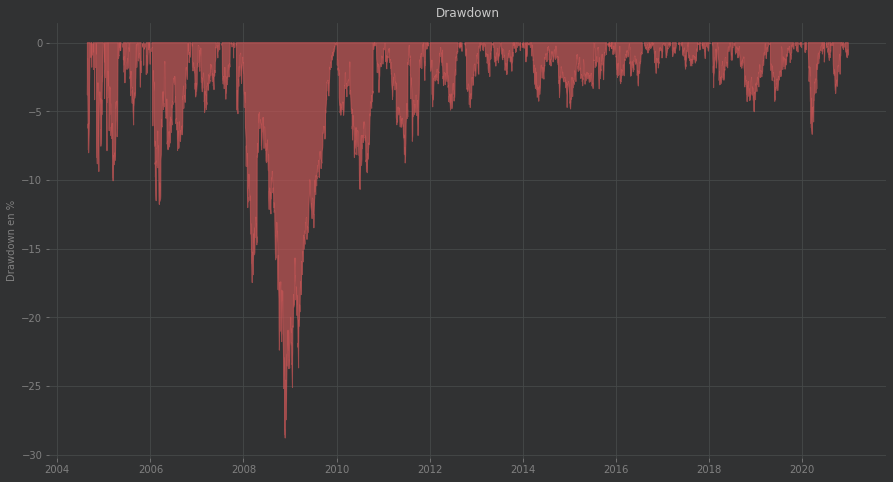

In [10]:
# Adaptar el tamaño de la figura
plt.figure(figsize=(15,8))

# Representar el drawdown
plt.fill_between(drawdown.index, drawdown*100, 0,
                 drawdown, color="#CE5757", alpha=0.65)

# Añadimos el título
plt.title("Drawdown")

# Etiqueta del eje de la y
plt.ylabel("Drawdown en %")

plt.show()


In [11]:
# Cálculo del drawdown máximo
max_drawdown = -np.min(drawdown)*100
print(f"Max drawdown: {'%.1f' % max_drawdown} %")

Max drawdown: 28.8 %


# Sección 3: Crear la función BackTest para evaluar la estrategia en las secciones posteriores

In [12]:
def BackTest(serie, annualiazed_scalar=252):

  # Importar el benchmark
  sp500 = yf.download("^GSPC", period="max", auto_adjust=False, multi_level_index=False)["Adj Close"].pct_change(1)
  
  # Cambiar el nombre
  sp500.name = "SP500"

  # Concatenar los retornos y el sp500
  val = pd.concat((serie,sp500), axis=1).dropna()
  # Calcular el drawdown
  drawdown = drawdown_function(serie)*100
  
  # Calcular el max drawdown
  max_drawdown = -np.min(drawdown)




  # Put a subplots
  fig, (cum, dra) = plt.subplots(1,2, figsize=(20,6))
  
  # Put a Suptitle
  fig.suptitle("Backtesting", size=20)

  # Returns cumsum chart
  cum.plot(serie.cumsum()*100, color="#39B3C7")

  # SP500 cumsum chart
  cum.plot(val["SP500"].cumsum()*100, color="#B85A0F")

  # Put a legend
  cum.legend(["Portfolio", "SP500"])
  
  # Set individual title
  cum.set_title("Cumulative Return", size=13)

  cum.set_ylabel("Cumulative Return %", size=11)

  # Put the drawdown
  dra.fill_between(drawdown.index,0,drawdown, color="#C73954", alpha=0.65)

  # Set individual title
  dra.set_title("Drawdown", size=13)

  dra.set_ylabel("drawdown en %", size=11)

  # Plot the graph
  plt.show()


  # Calcular el índice sortino
  sortino = np.sqrt(annualiazed_scalar) * serie.mean()/serie.loc[serie<0].std()

  # Calcular el índice  beta
  beta = np.cov(val[["return", "SP500"]].values,rowvar=False)[0][1] / np.var(val["SP500"].values)

  # Calcular el índice  alpha
  alpha = annualiazed_scalar * (serie.mean() - beta*serie.mean())

  # Imprimir los estadísticos
  print(f"Sortino: {np.round(sortino,3)}")
  print(f"Beta: {np.round(beta,3)}")
  print(f"Alpha: {np.round(alpha*100,3)} %")
  print(f"MaxDrawdown: {np.round(max_drawdown,3)} %")

# Aplicación

[*********************100%***********************]  1 of 1 completed
152/152 [==============================] - 0s 2ms/step


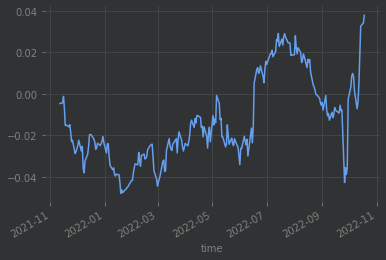

In [15]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"  # Keras 2, como en el vídeo (ver CAMBIOS-2026.md)
def preprocessing_yf(symbol):
  
  #Import the data
  df = yf.download(symbol, period="max", auto_adjust=False, multi_level_index=False)[["Open", "High", "Low", "Close", "Adj Close", "Volume"]].dropna()

  #Rename
  df.columns = ["open", "high", "low", "close", "adj close", "volume"]
  df.index.name = "time"

  # Remove adj close
  del df["adj close"]

  return df

def feature_engineering(df):
    """ Create new variables"""
    
    # We copy the dataframe to avoid interferences in the data
    df_copy = df.copy()
    
    # Create the returns
    df_copy["returns"] = df_copy["close"].pct_change(1)

    # Create the SMAs
    df_copy["SMA 15"] = df_copy[["close"]].rolling(15).mean().shift(1)
    df_copy["SMA 60"] = df_copy[["close"]].rolling(60).mean().shift(1)
    
    # Create the volatilities
    df_copy["MSD 10"] = df_copy[["returns"]].rolling(10).std().shift(1)
    df_copy["MSD 30"] = df_copy[["returns"]].rolling(30).std().shift(1)
    
    # Create the Rsi
    RSI = ta.momentum.RSIIndicator(df_copy["close"], window= 14, fillna = False)
    df_copy["rsi"] = RSI.rsi().shift(1)
    
    return df_copy.dropna()


import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import yfinance as yf
import ta
from sklearn.preprocessing import StandardScaler



df = preprocessing_yf("CADGBP=X")
dfc = feature_engineering(df)

# Percentage train set
split = int(0.85*len(dfc))
split_val = int(0.95*len(dfc))

# Train set creation
X_train = dfc[['SMA 15', 'SMA 60',
      'MSD 10', 'MSD 30', 'rsi']].iloc[:split,:]
y_train = dfc[["returns"]].iloc[:split]


# Test set creation
X_test = dfc[['SMA 15', 'SMA 60',
      'MSD 10', 'MSD 30', 'rsi']].iloc[split:,:]
y_test = dfc[["returns"]].iloc[split:]



# STANDARDISATION
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

def ANN_weights():
  nb_hidden_layer=2
  # INTIALIZATION SEQUENTIAL MODEL
  regressor = Sequential()

  # FIRST LAYER
  regressor.add(Dense(25, input_shape=(X_train_sc.shape[1],), activation="relu"))

  # ADD HIDDEN LAYER
  for i in range(1,nb_hidden_layer):
    regressor.add(Dense(int(25/i), activation="relu"))

  # OUTPUT LAYER DENSE
  regressor.add(Dense(1, activation="linear"))

  # COMPILE THE MODEL
  regressor.compile(loss="mse", optimizer=tensorflow.keras.optimizers.legacy.Adam())  # los pesos del repo se guardaron con este optimizador

  return regressor

ANN_models = ["ANN n17", "ANN n38", "ANN n66"]

# Create empty dataframe
prediction = pd.DataFrame(index = dfc.index)
for nb in ANN_models:

  # Create ANN structure
  ann = ANN_weights()

  # Import trained weights
  ann.load_weights(f"{nb}")

  # Create predictions for the whole dataset
  pre = ann.predict(np.concatenate((X_train_sc,X_test_sc),
                                        axis=0))
  prediction[f"{nb}"] = pre

prediction["Increase"] = (np.sign(prediction)==1).sum(axis=1)
prediction["Decrease"] = (np.sign(prediction)==-1).sum(axis=1)

# Put the daily return of the asset
prediction["returns"] = dfc["returns"]

# Compute the position doing a bagging on the best ANN
prediction["position"] = np.nan
prediction.loc[prediction["Increase"] > prediction["Decrease"], "position"] = 1
prediction.loc[prediction["Increase"] < prediction["Decrease"], "position"] = -1

# When you will run again the code you can have different results
# Compute and plot the strategy return on the validation test
# Very important to put the shift at he position,Don't forget!
prediction["strategy"] = prediction["returns"] * prediction["position"].shift(1)
split, split_val = int(0.85*len(dfc)), int(0.95*len(dfc))
prediction["strategy"].iloc[split_val:].cumsum().plot()

[*********************100%***********************]  1 of 1 completed


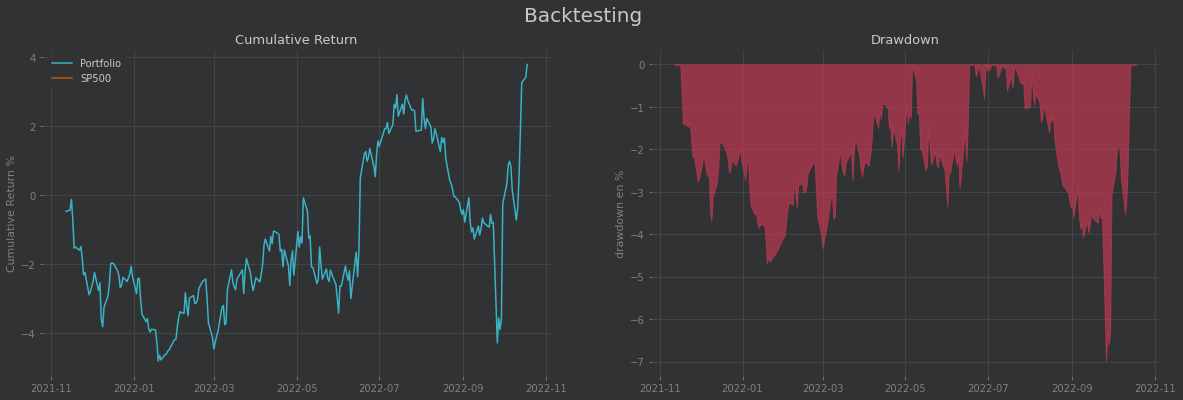

Sortino: 0.663
Beta: nan
Alpha: nan %
MaxDrawdown: 6.985 %


In [17]:
prediction["return"] = prediction["strategy"]

BackTest(prediction["return"].iloc[split_val:])